In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
h = 0.6774

In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [8]:
group_sfr = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


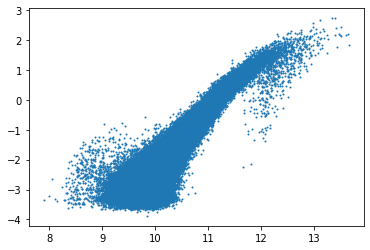

In [15]:
plt.scatter(mvir, group_sfr,s=1)

In [28]:
np.mean(halos["GroupSFR"][halos["GroupSFR"]<0.1])

0.0002093618

In [32]:
np.std(halos["GroupSFR"][mvir<12])

0.25015593

In [14]:
np.sum(halos["GroupSFR"]>0)/0.75**3

362557.6296296296

In [33]:
np.mean(halos["GroupSFR"][halos["GroupSFR"]<0.001])

2.9404134e-06

In [18]:
def compute_shotnoise(data, boxsize, weighting="LIM"):
    if weighting == "LIM":
        sum_w = np.sum(data)
        sum_w2 = np.sum(data**2)
    elif weighting == 1:
        sum_w = len(data)
        sum_w2 = len(data)
    else:
        raise ValueError("Not valid weighting")

    # print(boxsize**3)
    # print(sum_w2)
    # print(sum_w**2)
    

    shotnoise = boxsize**3 * sum_w2 / sum_w**2
    return shotnoise

In [19]:
compute_shotnoise(halos["GroupSFR"], 75)

236.69041165644163